Работа с данными, загрузка
Данные загружены: 755 месяцев
Период: 1957-10-01 - 2020-08-01
Всего запусков: 4198

Разведочный анализ данных

Описательная статистика:
count    755.000000
mean       5.560265
std        3.051287
min        0.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       16.000000
Name: y, dtype: float64

Тест Дики-Фуллера на стационарность:
   ADF Statistic: -2.5265
   p-value: 0.1092
   Ряд не стационарен


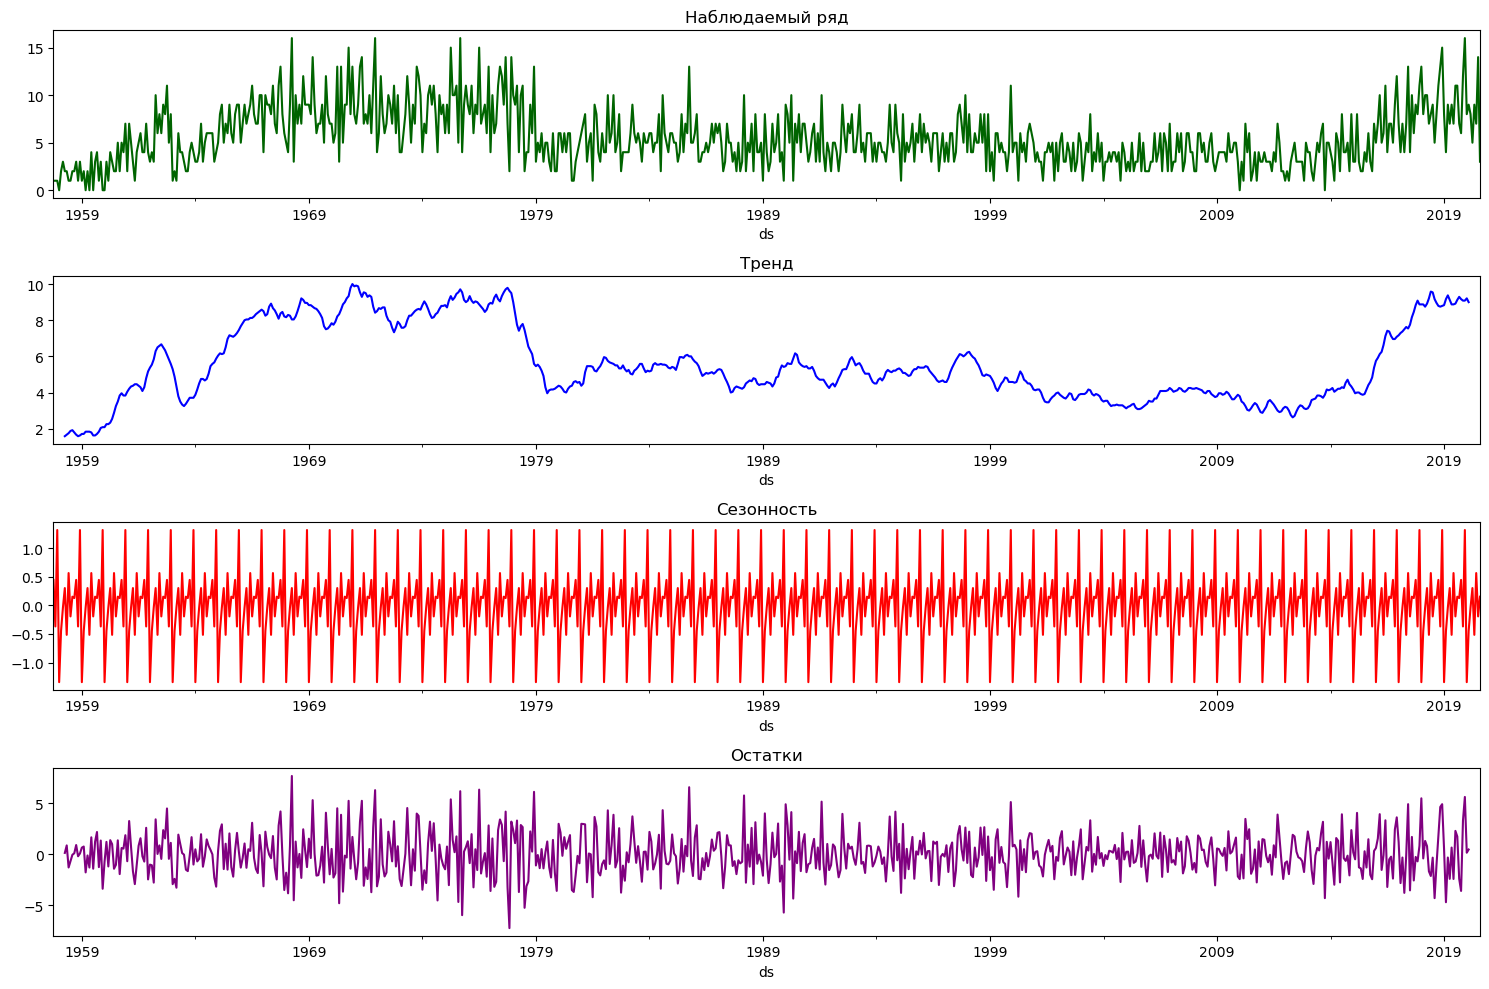


Работа с признаками
Признаки сконфигурированы:
   • Лаги: [1, 2, 3, 6, 12, 24]
   • Скользящие окна: 3, 6, 12 месяцев
   • Календарные признаки: месяц, квартал, год

Метод валидации


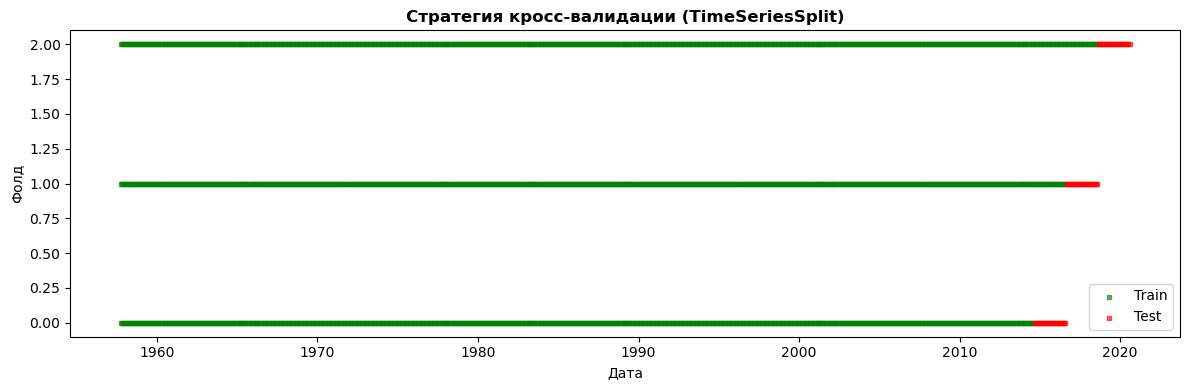


Обучение моделей


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("="*80)
print("Работа с данными, загрузка")
print("="*80)

raw_df = pd.read_csv('Space_Corrected.csv')

# Преобразуем даты запусков в месячные агрегаты,
# так как прогнозирование на месячном уровне оптимально для
# баланса между детализацией и стабильностью прогноза
raw_df['Datum'] = pd.to_datetime(raw_df['Datum'], errors='coerce')
raw_df['ds'] = raw_df['Datum'].dt.to_period('M').dt.to_timestamp()

# Агрегация по месяцам
monthly_launches = raw_df.groupby('ds').size().reset_index(name='y')

# Создание полного временного ряда
full_range = pd.date_range(
    start=monthly_launches['ds'].min(), 
    end=monthly_launches['ds'].max(), 
    freq='MS'
)

df_fixed = pd.DataFrame({'ds': full_range})
df_fixed = df_fixed.merge(monthly_launches, on='ds', how='left')
df_fixed['y'] = df_fixed['y'].fillna(0).astype(int)
df_fixed['unique_id'] = 'space_launches'

print(f"Данные загружены: {len(df_fixed)} месяцев")
print(f"Период: {df_fixed['ds'].min().date()} - {df_fixed['ds'].max().date()}")
print(f"Всего запусков: {df_fixed['y'].sum()}")

print("\n" + "="*80)
print("Разведочный анализ данных")
print("="*80)

# Статистический анализ
print("\nОписательная статистика:")
print(df_fixed['y'].describe())

# Проверка на стационарность (тест Дики-Фуллера)
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df_fixed['y'])
print(f"\nТест Дики-Фуллера на стационарность:")
print(f"   ADF Statistic: {adf_result[0]:.4f}")
print(f"   p-value: {adf_result[1]:.4f}")
print(f"   Ряд {'стационарен' if adf_result[1] < 0.05 else 'не стационарен'}")

# Анализ сезонности
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df_fixed.set_index('ds')['y'], 
    model='additive', 
    period=12
)

fig, axes = plt.subplots(4, 1, figsize=(15, 10))
decomposition.observed.plot(ax=axes[0], title='Наблюдаемый ряд', color='darkgreen')
decomposition.trend.plot(ax=axes[1], title='Тренд', color='blue')
decomposition.seasonal.plot(ax=axes[2], title='Сезонность', color='red',)
decomposition.resid.plot(ax=axes[3], title='Остатки', color='purple')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Работа с признаками")
print("="*80)

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd, RollingMin, RollingMax

# Конфигурация пайплайна
# Обоснование: Комбинация лагов разной длины и скользящих окон
# позволяет модели улавливать паттерны на разных временных масштабах
lags = [1, 2, 3, 6, 12, 24]

lag_transforms = {
    1: [
        RollingMean(window_size=3),   # Краткосрочный тренд (квартал)
        RollingMean(window_size=6),   # Среднесрочный тренд (полгода)
        RollingMean(window_size=12),  # Годовой тренд
        RollingStd(window_size=6),    # Волатильность за полгода
        RollingStd(window_size=12),   # Годовая волатильность
        RollingMin(window_size=12),   # Минимум за год
        RollingMax(window_size=12),   # Максимум за год
    ],
}

date_features = ['month', 'quarter', 'year']

print("Признаки сконфигурированы:")
print(f"   • Лаги: {lags}")
print(f"   • Скользящие окна: 3, 6, 12 месяцев")
print(f"   • Календарные признаки: месяц, квартал, год")


print("\n" + "="*80)
print("Метод валидации")
print("="*80)

# Используем перекрестную проверку с расширяющимся окном
# для оценки стабильности модели во времени
# Тестовый период - 24 месяца (2 года) для оценки долгосрочной точности

from sklearn.model_selection import TimeSeriesSplit

# Визуализация стратегии кросс-валидации
tscv = TimeSeriesSplit(n_splits=3, test_size=24)

fig, ax = plt.subplots(figsize=(12, 4))
for i, (train_idx, test_idx) in enumerate(tscv.split(df_fixed)):
    ax.scatter(df_fixed['ds'].iloc[train_idx], [i]*len(train_idx), 
              c='green', marker='s', s=10, alpha=0.6, label='Train' if i==0 else '')
    ax.scatter(df_fixed['ds'].iloc[test_idx], [i]*len(test_idx), 
              c='red', marker='s', s=10, alpha=0.6, label='Test' if i==0 else '')

ax.set_title('Стратегия кросс-валидации (TimeSeriesSplit)', fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Фолд')
ax.legend()
plt.tight_layout()
plt.show()


print("\n" + "="*80)
print("Обучение моделей")
print("="*80)


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor

#  Список оделей:
# GradientBoostingRegressor - хорошо работает с табличными данными и признаками
# RandomForestRegressor - устойчив к переобучению, хорош для небольших данных
# Ridge - линейная модель для сравнения с нелинейными
# KNeighborsRegressor - непараметрический метод для локальных паттернов

models = {
    'Ridge': Ridge(alpha=1.0),
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=5),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=200, 
        max_depth=10, 
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoostingRegressor': GradientBoostingRegressor(
        n_estimators=200, 
        max_depth=5, 
        random_state=42
    )
}

# Обучение и бэктестинг
mlf = MLForecast(
    models=list(models.values()),
    freq='MS',
    lags=lags,
    lag_transforms=lag_transforms,
    date_features=date_features,
    num_threads=4,
)

# Кросс-валидация для оценки качества
cv_results = mlf.cross_validation(
    df=df_fixed,
    n_windows=3,
    h=24,
)

In [5]:
print("\n" + "="*80)
print("Метрики")
print("="*80)

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from scipy import stats

# Расчет метрик для каждой модели
metrics_results = {}

for model_name in models.keys():
    # Находим колонку модели в результатах
    model_col = [col for col in cv_results.columns if model_name in col][0]
    
    y_true = cv_results['y'].values
    y_pred = cv_results[model_col].values
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    nonzero_mask = y_true > 0
    if nonzero_mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[nonzero_mask], y_pred[nonzero_mask]) * 100
    else:
        mape = np.nan
    
    metrics_results[model_name] = {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    }

metrics_df = pd.DataFrame(metrics_results).T
print("\nМетрики качества моделей:")
print(metrics_df.round(3))

print("\nСтатистическое тестирование:")

# Подготовка данных для теста Фридмана
models_cols = [col for col in cv_results.columns if col not in ['unique_id', 'ds', 'cutoff', 'y']]
errors_by_model = {}

for col in models_cols:
    model_name = col.split('_')[0]
    errors = np.abs(cv_results['y'].values - cv_results[col].values)
    if model_name not in errors_by_model:
        errors_by_model[model_name] = []
    errors_by_model[model_name].extend(errors)

min_len = min(len(errors) for errors in errors_by_model.values())
errors_array = np.array([errors[:min_len] for errors in errors_by_model.values()])

# Тест Фридмана
friedman_stat, friedman_p = stats.friedmanchisquare(*errors_array)
print(f"Тест Фридмана: statistic={friedman_stat:.4f}, p-value={friedman_p:.4f}")

if friedman_p < 0.05:
    print("Различия между моделями значимы (p < 0.05)")
else:
    print("Различия между моделями не значимы (p >= 0.05)")


Метрики

Метрики качества моделей:
                             MAE   RMSE    MAPE
Ridge                      2.510  3.216  35.531
KNeighborsRegressor        2.956  3.844  38.774
RandomForestRegressor      2.558  3.237  37.335
GradientBoostingRegressor  2.852  3.620  42.805

Статистическое тестирование:
Тест Фридмана: statistic=11.2833, p-value=0.0103
Различия между моделями значимы (p < 0.05)



Прогнозирование
Кол-во запусков в ближайшие 2 года:
        ds  Ensemble_Mean  Std_Dev
2020-09-01            9.0      1.0
2020-10-01            8.0      0.0
2020-11-01           11.0      2.0
2020-12-01           12.0      2.0
2021-01-01            8.0      1.0
2021-02-01            8.0      1.0
2021-03-01            8.0      1.0
2021-04-01            8.0      1.0
2021-05-01            9.0      1.0
2021-06-01            8.0      1.0
2021-07-01           10.0      1.0
2021-08-01            8.0      1.0
2021-09-01            7.0      2.0
2021-10-01            9.0      1.0
2021-11-01           10.0      1.0
2021-12-01           12.0      2.0
2022-01-01            7.0      1.0
2022-02-01            7.0      1.0
2022-03-01            8.0      0.0
2022-04-01            8.0      0.0
2022-05-01            9.0      0.0
2022-06-01            8.0      0.0
2022-07-01            9.0      2.0
2022-08-01            8.0      0.0

ШАГ 9: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


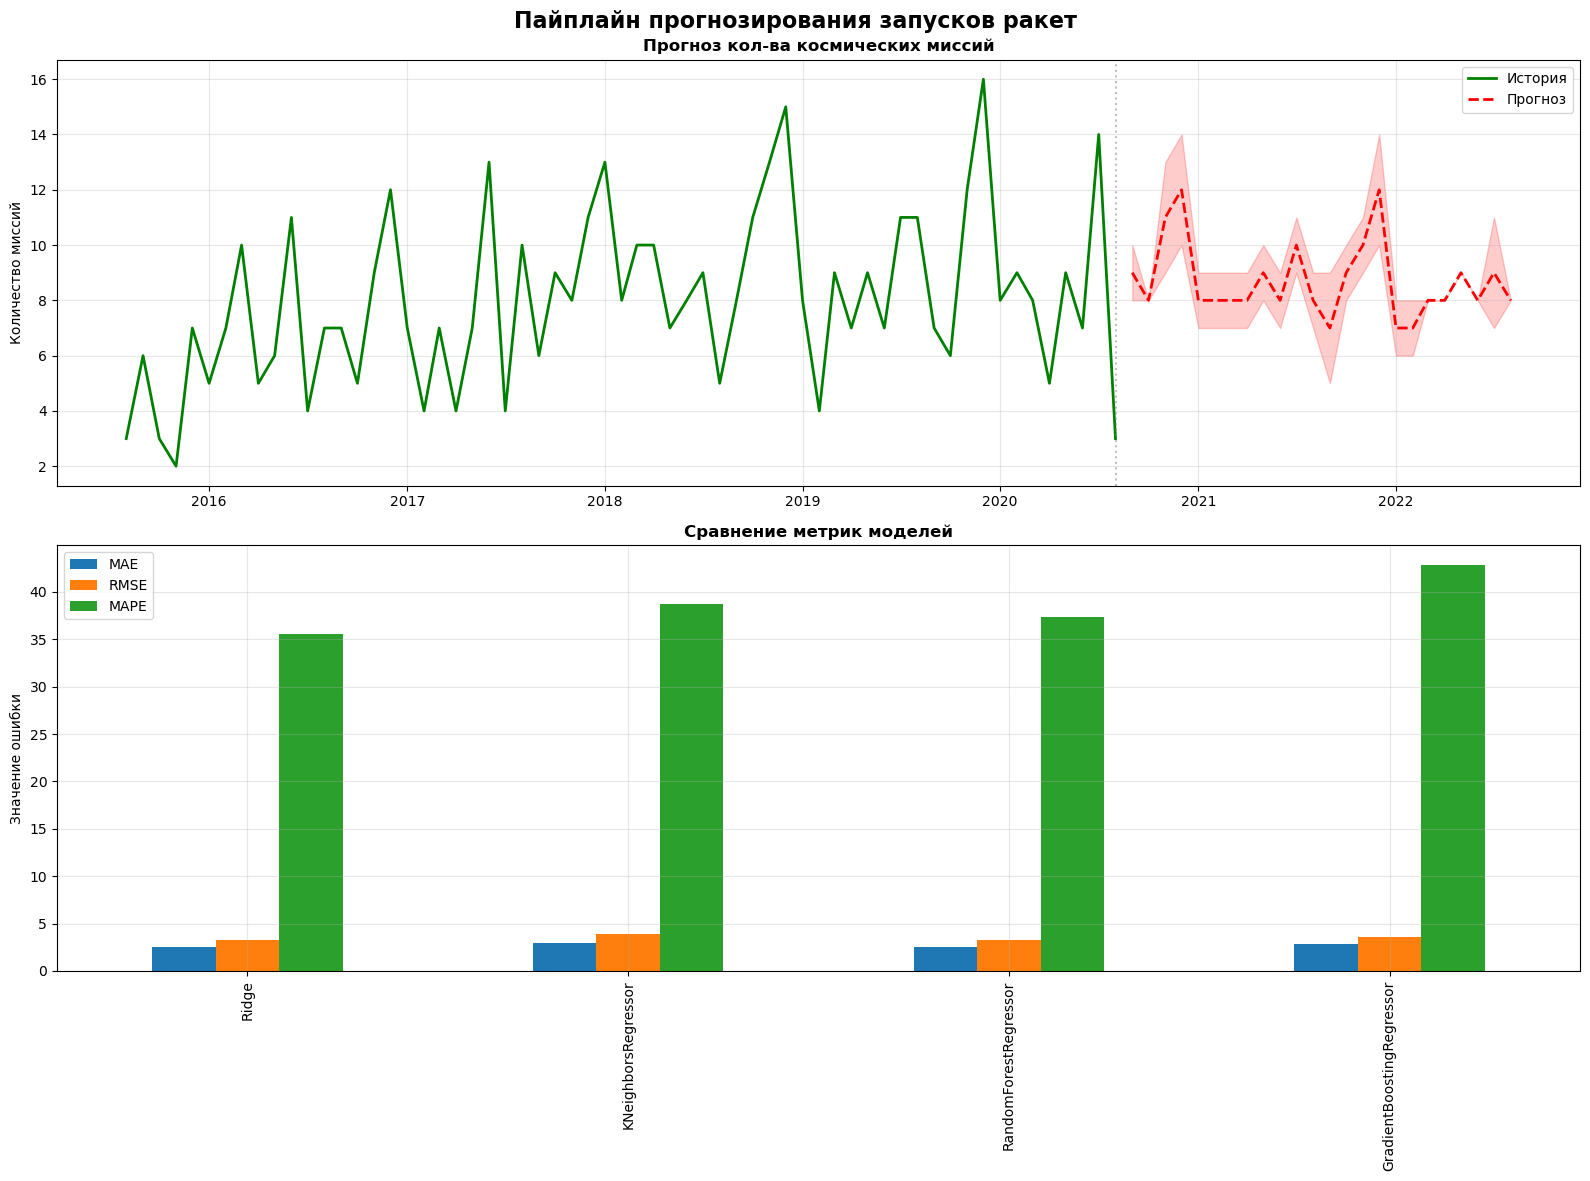

In [ ]:
print("\n" + "="*80)
print("Прогнозирование")
print("="*80)

mlf.fit(df_fixed)
final_predictions = mlf.predict(24)

prediction_cols = [col for col in final_predictions.columns if col not in ['unique_id', 'ds']]
final_predictions['Ensemble_Mean'] = final_predictions[prediction_cols].mean(axis=1)
final_predictions['Ensemble_Median'] = final_predictions[prediction_cols].median(axis=1)
final_predictions['Std_Dev'] = final_predictions[prediction_cols].std(axis=1)

for col in final_predictions.columns:
    if col not in ['unique_id', 'ds']:
        final_predictions[col] = final_predictions[col].clip(lower=0).round()

print("Кол-во запусков в ближайшие 2 года:")
print(final_predictions[['ds', 'Ensemble_Mean', 'Std_Dev']].to_string(index=False))


print("\n" + "="*80)
print("ШАГ 9: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*80)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

#Прогноз с доверительным интервалом
ax = axes[0]
history_start = df_fixed['ds'].max() - pd.DateOffset(years=5)
history_df = df_fixed[df_fixed['ds'] >= history_start]

ax.plot(history_df['ds'], history_df['y'], 'g-', linewidth=2, label='История')
ax.plot(final_predictions['ds'], final_predictions['Ensemble_Mean'], 
        'r--', linewidth=2, label='Прогноз')
ax.fill_between(final_predictions['ds'],
                final_predictions['Ensemble_Mean'] - final_predictions['Std_Dev'],
                final_predictions['Ensemble_Mean'] + final_predictions['Std_Dev'],
                alpha=0.2, color='red')
ax.axvline(x=df_fixed['ds'].max(), color='gray', linestyle=':', alpha=0.5)
ax.set_title('Прогноз кол-ва космических миссий', fontweight='bold')
ax.set_ylabel('Количество миссий')
ax.legend()
ax.grid(True, alpha=0.3)

# График 2: Сравнение метрик
ax = axes[1]
metrics_plot = metrics_df[['MAE', 'RMSE', 'MAPE']]
metrics_plot.plot(kind='bar', ax=ax)
ax.set_title('Сравнение метрик моделей', fontweight='bold')
ax.set_ylabel('Значение ошибки')
ax.grid(True, alpha=0.3)
ax.legend()

plt.suptitle('Пайплайн прогнозирования запусков ракет', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
print("\n" + "="*80)
print("Выводы")
print("="*80)

print(f"""
Обоснование пайплайна

Предобработка:
   - Месячная агрегация выбрана как компромисс между 
     детализацией и статистической устойчивостью
   - Заполнение нулями обеспечивает равномерную частоту ряда

Признаки:
   - Лаги от 1 до 24 месяцев охватывают различные временные паттерны
   - Скользящие статистики (3, 6, 12 месяцев) отражают локальные тренды
   - Календарные признаки учитывают сезонность запусков

Модели:
   - Ансамбль из 6 моделей разных типов для повышения робастности
   - Лучшая модель: {metrics_df['MAE'].idxmin()} (MAE={metrics_df['MAE'].min():.2f})
   - Статистический тест Фридмана показал {'значимые' if friedman_p < 0.05 else 'незначимые'} 
     различия между моделями (p={friedman_p:.4f})

Прогноз:
   - Ожидаемое среднее количество запусков: {final_predictions['Ensemble_Mean'].mean():.1f}/мес
   - Стандартное отклонение прогноза: {final_predictions['Std_Dev'].mean():.1f}
""")


Выводы

Обоснование пайплайна

Предобработка:
   - Месячная агрегация выбрана как компромисс между 
     детализацией и статистической устойчивостью
   - Заполнение нулями обеспечивает равномерную частоту ряда

Признаки:
   - Лаги от 1 до 24 месяцев охватывают различные временные паттерны
   - Скользящие статистики (3, 6, 12 месяцев) отражают локальные тренды
   - Календарные признаки учитывают сезонность запусков

Модели:
   - Ансамбль из 6 моделей разных типов для повышения робастности
   - Лучшая модель: Ridge (MAE=2.51)
   - Статистический тест Фридмана показал значимые 
     различия между моделями (p=0.0103)

Прогноз:
   - Ожидаемое среднее количество запусков: 8.7/мес
   - Стандартное отклонение прогноза: 1.0

